In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("cleaned_data.csv")

In [3]:
X = df.drop("GoodFT", axis=1)
y = df["GoodFT"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
#n_estimators=100 means the model will build 100 sequential trees (take 100 practice tests).
# max_depth=3 means each tree is relatively small, so it doesn't overthink and memorize the data.
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

In [6]:
gb_model.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [7]:
y_pred = gb_model.predict(X_test)

In [8]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Gradient Boosting Accuracy: {accuracy * 100:.2f}%\n")
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred))

Gradient Boosting Accuracy: 68.02%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.66      0.66      1920
           1       0.70      0.70      0.70      2126

    accuracy                           0.68      4046
   macro avg       0.68      0.68      0.68      4046
weighted avg       0.68      0.68      0.68      4046



In [9]:
cm = confusion_matrix(y_test, y_pred)

<Axes: >

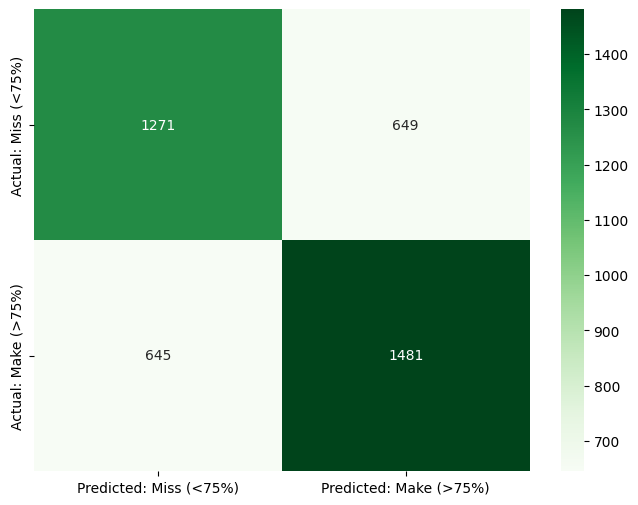

In [10]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Predicted: Miss (<75%)', 'Predicted: Make (>75%)'], 
            yticklabels=['Actual: Miss (<75%)', 'Actual: Make (>75%)'])

In [11]:
plt.savefig('gb_confusion_matrix.png', bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [12]:
df['GoodFT'].value_counts(normalize=True)

GoodFT
1    0.524226
0    0.475774
Name: proportion, dtype: float64